# Telecom Customer Churn Prediction

---

## 1. Problem Description

### Problem Statement
Customer churn is a critical challenge for telecom companies. Churn occurs when a customer stops using a company's services and switches to a competitor. Retaining existing customers is significantly cheaper than acquiring new ones — making churn prediction a high-value business problem.

### Goal
Build a **binary classification model** that predicts whether a telecom customer will churn (`Yes`) or not (`No`) based on demographic, account, and service-related features.

The trained model will help the business:
- Effectively identify at-risk customers while keeping false alarms manageable
- Design targeted retention campaigns based on these insights
- Reduce revenue loss due to customer attrition

### Features Description

| Feature | Type | Description |
|---|---|---|
| `customerID` | Categorical (ID) | Unique customer identifier — will be **dropped** |
| `gender` | Binary Categorical | Customer gender: `Male` / `Female` |
| `SeniorCitizen` | Binary (0/1) | Whether the customer is a senior citizen |
| `Partner` | Binary Categorical | Whether the customer has a partner: `Yes` / `No` |
| `Dependents` | Binary Categorical | Whether the customer has dependents: `Yes` / `No` |
| `tenure` | Numerical (int) | Number of months the customer has been with the company (0–72) |
| `PhoneService` | Binary Categorical | Whether the customer has phone service: `Yes` / `No` |
| `MultipleLines` | Categorical | Multiple phone lines: `Yes` / `No` / `No phone service` |
| `InternetService` | Categorical | Type of internet service: `DSL` / `Fiber optic` / `No` |
| `OnlineSecurity` | Categorical | Online security add-on: `Yes` / `No` / `No internet service` |
| `OnlineBackup` | Categorical | Online backup add-on: `Yes` / `No` / `No internet service` |
| `DeviceProtection` | Categorical | Device protection add-on: `Yes` / `No` / `No internet service` |
| `TechSupport` | Categorical | Tech support add-on: `Yes` / `No` / `No internet service` |
| `StreamingTV` | Categorical | TV streaming add-on: `Yes` / `No` / `No internet service` |
| `StreamingMovies` | Categorical | Movie streaming add-on: `Yes` / `No` / `No internet service` |
| `Contract` | Categorical | Contract type: `Month-to-month` / `One year` / `Two year` |
| `PaperlessBilling` | Binary Categorical | Paperless billing: `Yes` / `No` |
| `PaymentMethod` | Categorical | Payment method: 4 categories |
| `MonthlyCharges` | Numerical (float) | Monthly charge amount in USD |
| `TotalCharges` | Numerical (float) | Total charges over tenure in USD (stored as string — needs conversion) |

### Target Variable
- **`Churn`** — Whether the customer churned: `Yes` / `No`

### Metrics
| Metric | Description |
| --- | --- |
| **Recall** | proportion of actual positives correctly identified |
| **Precision** | proportion of predicted positives that are truly positive |
| **F1-Score** | balances precision and recall into one measure |
| **PR-AUC** | measures model performance under class imbalance across all thresholds |
---

## 2. Import Libraries & Config

In [1]:
# ── Core ──
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import joblib

# ── Visualisation ──
import matplotlib.pyplot as plt
import seaborn as sns

# ── Plot Style ──
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

# ── Preprocessing ──
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

# ── Model Selection & Splitting ──
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold, cross_validate, cross_val_predict

# ── Models ──
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# ── Evaluation Metrics ──
from sklearn.metrics import (
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_auc_score, roc_curve,
    f1_score, precision_score, recall_score, 
    average_precision_score, precision_recall_curve
)

# ── Feature Importance and Selection ──
from sklearn.feature_selection import SelectKBest, chi2

# ── Configuration ──
RANDOM_STATE  = 42
MODEL_PATH    = '../model/best_model_pipeline.pkl'
TARGET        = 'Churn'
CV_FOLDS      = 5

---
## 3. Data Loading and Discovery

Load the telecom customer churn dataset, inspect its shape, data types, duplicates, and missing values to understand what we are working with before any transformation.

In [2]:
df = pd.read_csv('../data/telecom customer churn.csv')
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
df.head(10)

Rows: 7,043  |  Columns: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [3]:
print("── Data Types ──")
print(df.dtypes)

── Data Types ──
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [4]:
print("── Basic Info ──")
df.info()

── Basic Info ──
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   st

#### **Note:**
- **TotalCharges** column is stored as an object, not as an integer or float. This might happens because it contains 11 entries with blank spaces, which are treated as non-null strings. These will be handled during preprocessing.

In [5]:
print("── Descriptive Statistics ──")
df.describe(include='all').T

── Descriptive Statistics ──


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Remove customerID column
df = df.drop(columns=['customerID'])

In [7]:
# ── Duplicates ──
n_dup = df.duplicated().sum()
print(f"Duplicated rows: {n_dup}")

# ── Null values ──
null_counts = df.isnull().sum()
print(f"\nNull value counts:\n{null_counts}")

Duplicated rows: 22

Null value counts:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


### Data Loading Summary
- Dataset has **7,043 rows** and **21 columns**
- **22 Duplicated rows** detected
- **`TotalCharges`** is stored as `object` (string). It contains **11 blank-space entries** that must be handled as missing values during preprocessing.
- **`customerID`** is a unique identifier with no predictive value — It was dropped.
---

## 4. Data Preprocessing
remove duplicated rows, outliers detection and treatment, Fix TotalCharges column data type, and encode the target

In [8]:
# ── Remove Duplicates ──
df = df.drop_duplicates()
print(f"Rows remaining: {len(df):,}")

Rows remaining: 7,021


In [9]:
# ── Fix TotalCharges data type — convert to float ──
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"TotalCharges NaN after conversion: {df['TotalCharges'].isna().sum()}")

# ── Drop rows with missing TotalCharges ──
df = df.dropna(subset=['TotalCharges'])
print(f"Number of rows after dropping nulls: {df.shape[0]}")

TotalCharges NaN after conversion: 11
Number of rows after dropping nulls: 7010


In [10]:
# ── Outlier Detection ──
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

print("--- IQR-Based Outlier Detection ---")
outlier_summary = {}

for col in numerical_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"  {col:} outliers found: {n_out:}")

--- IQR-Based Outlier Detection ---
  tenure outliers found: 0
  MonthlyCharges outliers found: 0
  TotalCharges outliers found: 0


In [11]:
df[TARGET] = df[TARGET].map({'Yes': 1, 'No': 0})

### Preprocessing Summary
- **Duplicates**: 22 identical rows removed
- **TotalCharges**: Converted from `object` to `float64`; 11 blank-space entries dropped
- **Outliers**: None detected in the three continuous features — no capping required
- **Target feature** has been encoded
---

## 5. Exploratory Data Analysis (EDA)

### 5.1 Univariate Analysis — Numerical Features

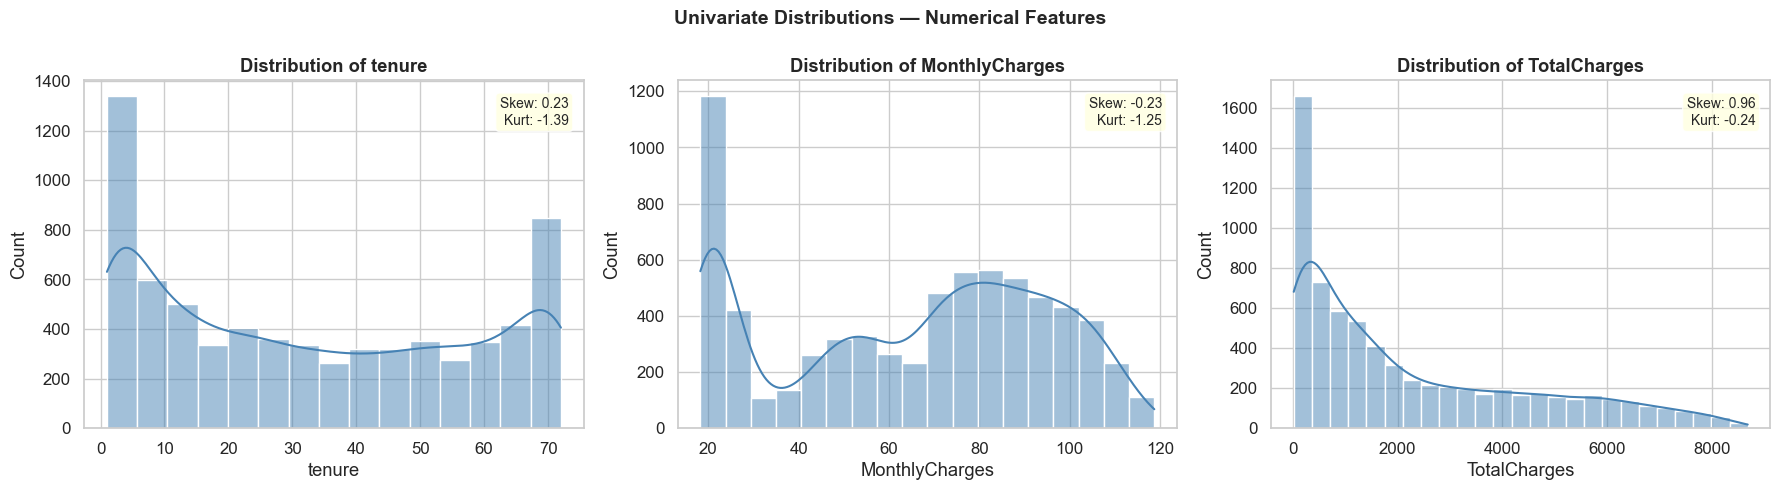

Feature                Skewness   Kurtosis
------------------------------------------
tenure                    0.234     -1.389
MonthlyCharges           -0.226     -1.253
TotalCharges              0.958     -0.238


In [12]:
# ── Histogram + KDE for each numerical feature ──
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, numerical_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'Distribution of {col}', fontweight='bold')
    ax.set_xlabel(col)
    skew = df[col].skew()
    kurt = df[col].kurtosis()
    ax.text(0.97, 0.95, f'Skew: {skew:.2f}\nKurt: {kurt:.2f}', transform=ax.transAxes, ha='right', va='top',
            fontsize=10, bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle('Univariate Distributions — Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"{'Feature':<20} {'Skewness':>10} {'Kurtosis':>10}")
print("-" * 42)
for col in numerical_cols:
    print(f"{col:<20} {df[col].skew():>10.3f} {df[col].kurtosis():>10.3f}")

**Key Insights — Numerical Univariate:**
- **`tenure`**: Bimodal distribution — large spikes at near-zero (new customers) and ~70 months (long-term customers). This is a strong churn signal.
- **`MonthlyCharges`**: Slightly right-skewed with a peak around 20 and a second cluster around 70–90$, suggesting  distinct pricing tiers.
- **`TotalCharges`**: Heavily right-skewed because it accumulates over tenure — new customers contribute little, driving the long left tail.
- **Modeling impact**: `TotalCharges` may benefit from log-transformation in linear models. Tree-based models are unaffected by skewness.

### 5.2 Univariate Analysis — Categorical Features

In [13]:
def plot_counts(cols, title_prefix, figsize=(18, 10)):
    n_cols = 3
    n_rows = (len(cols) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten()
    
    for i, col in enumerate(cols):
        series = df[col].replace({0: "No", 1: "Yes"}) if col == "SeniorCitizen" else df[col]
        val_counts = series.value_counts()
        sns.barplot(x=val_counts.index, y=val_counts.values, ax=axes[i], palette='Blues_d', edgecolor='white')
        axes[i].set_title(col)
        axes[i].set_ylabel('Count')
        axes[i].tick_params(axis='x', rotation=30)
        total = val_counts.sum()
        for patch in axes[i].patches:
            height = patch.get_height()
            if height > 0:
                pct = f'{height / total * 100:.1f}%'
                axes[i].text(
                    patch.get_x() + patch.get_width() / 2,
                    height + total * 0.01,
                    pct,
                    ha='center', va='bottom',
                    fontsize=12, fontweight='bold'
                )
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
        
    plt.suptitle(f'{title_prefix}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

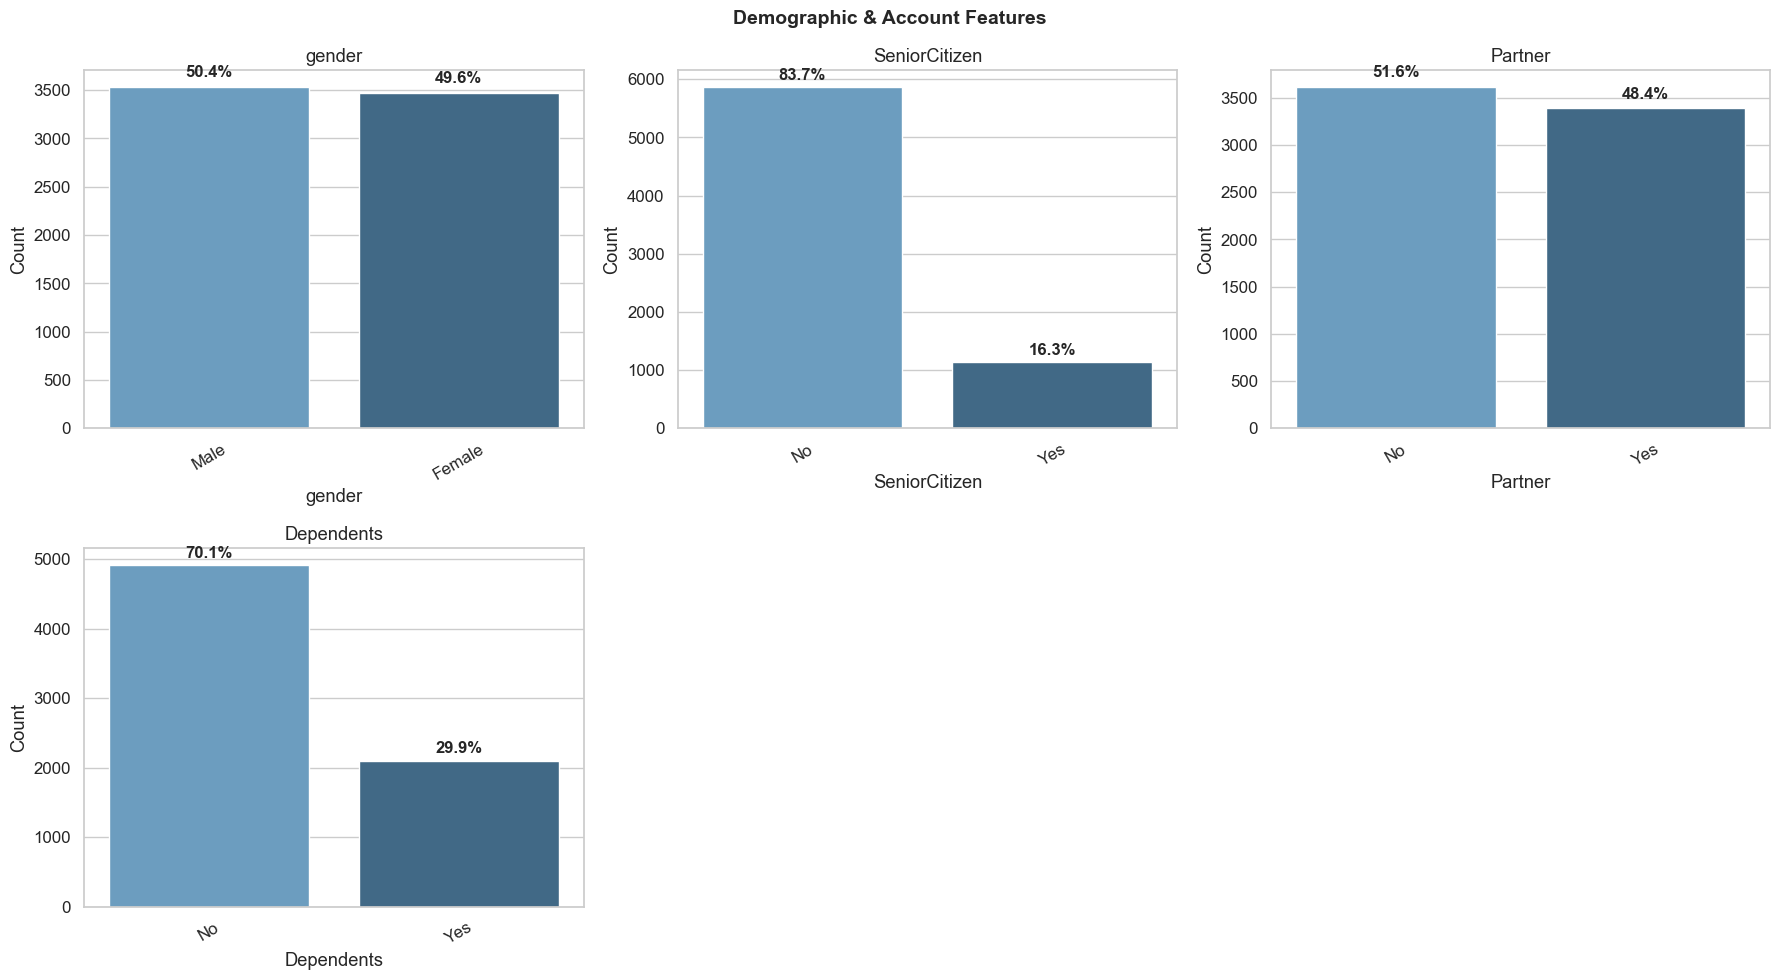

In [14]:
plot_counts(df.columns[:4],  'Demographic & Account Features')

- **`Gender`**: Balanced distribution -> Male (50.4%) vs Female (49.6%)
- **`SeniorCitizen`**: Only 16% of customers are seniors.
- **`Partner & Dependents`**: Majority have no partner and no dependents

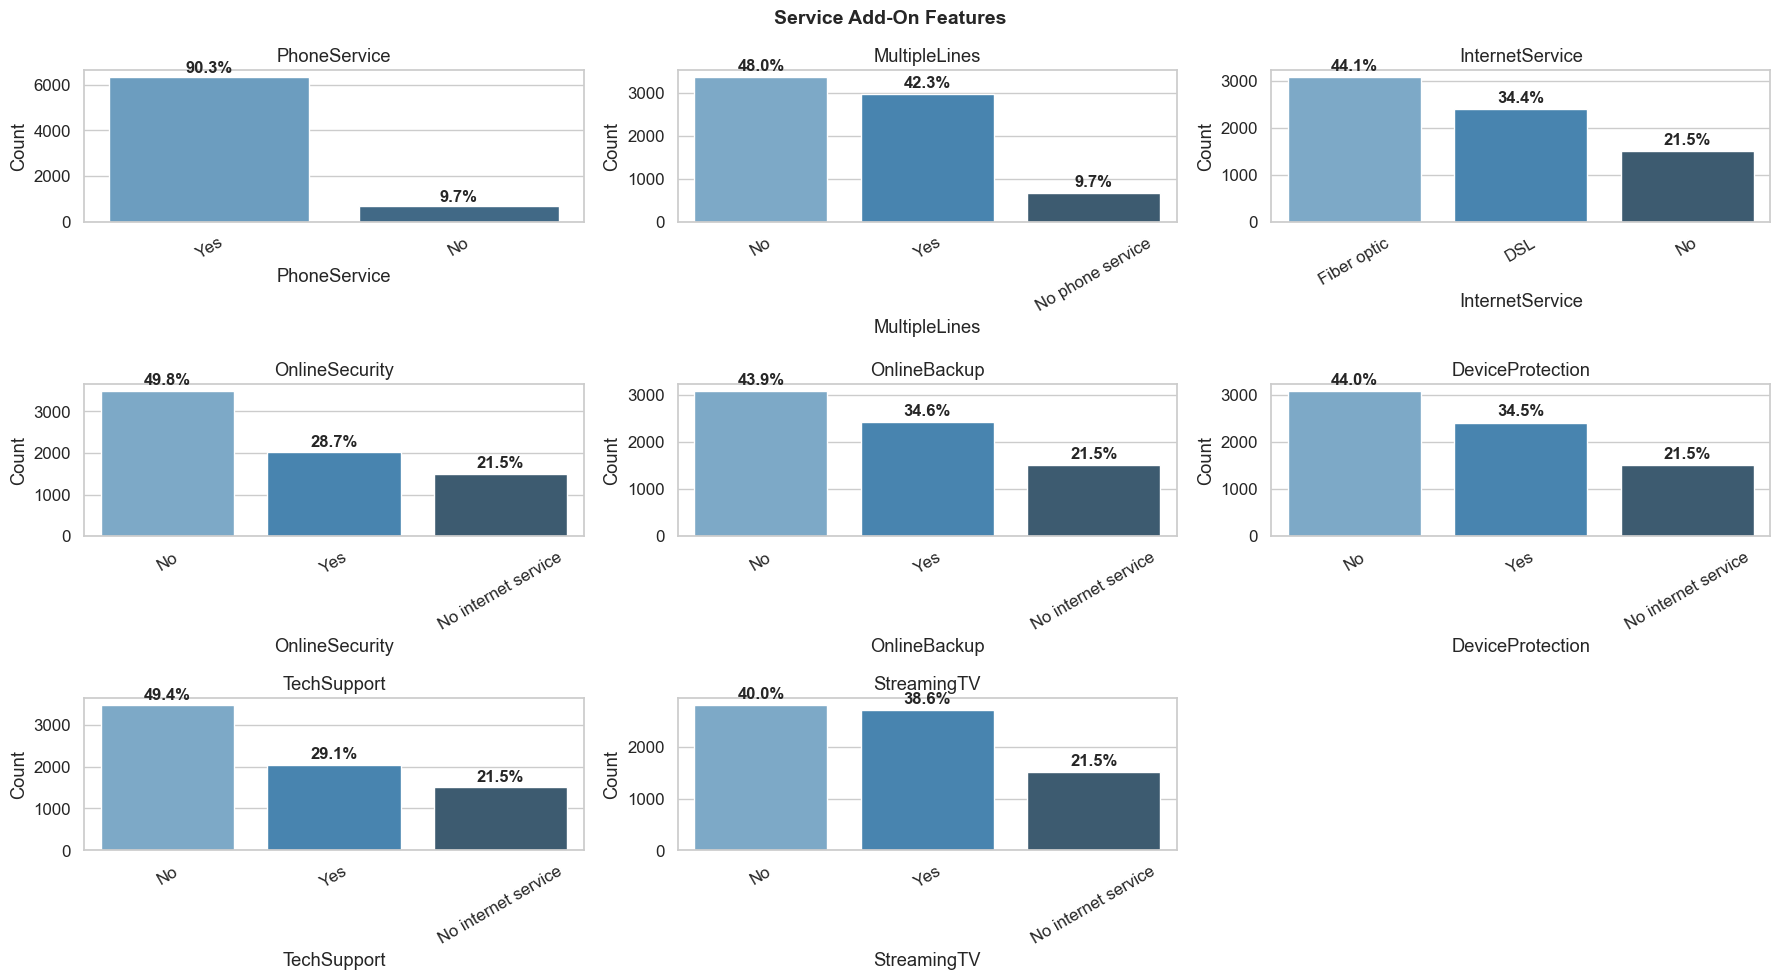

In [15]:
plot_counts(df.columns[5:13], 'Service Add-On Features')

- **`Security/Support Add‑ons (OnlineSecurity, TechSupport, DeviceProtection, Backup)`**: Most customers do not subscribe (65-71% “No”).
- **`Streaming Services (TV & Movies)`**: adopted by about 36-39% (Yes).

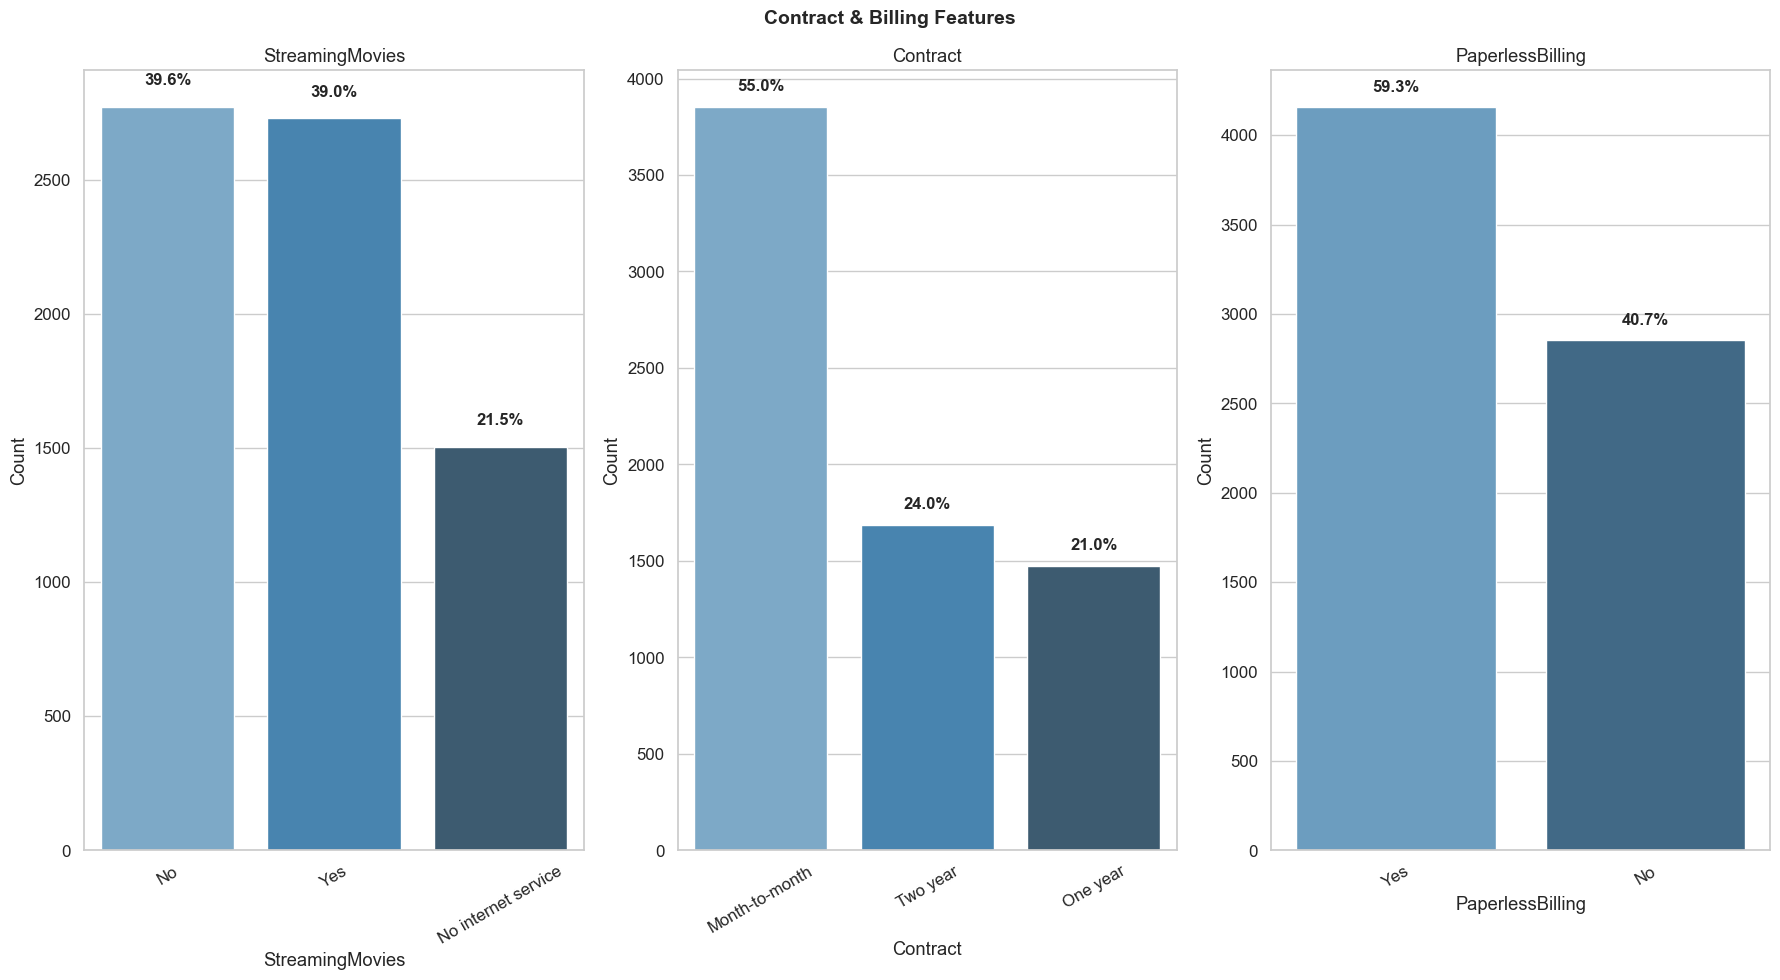

In [16]:
plot_counts(df.columns[13:16], 'Contract & Billing Features')

- **`Contract`**: Dominated by `Month-to-month` (55%) — the most churn-risky contract type.
- **`PaymentMethod`**: Fairly balanced across four categories; `Electronic check` is the most common.

### 5.3 Bivariate Analysis — Numerical vs Target

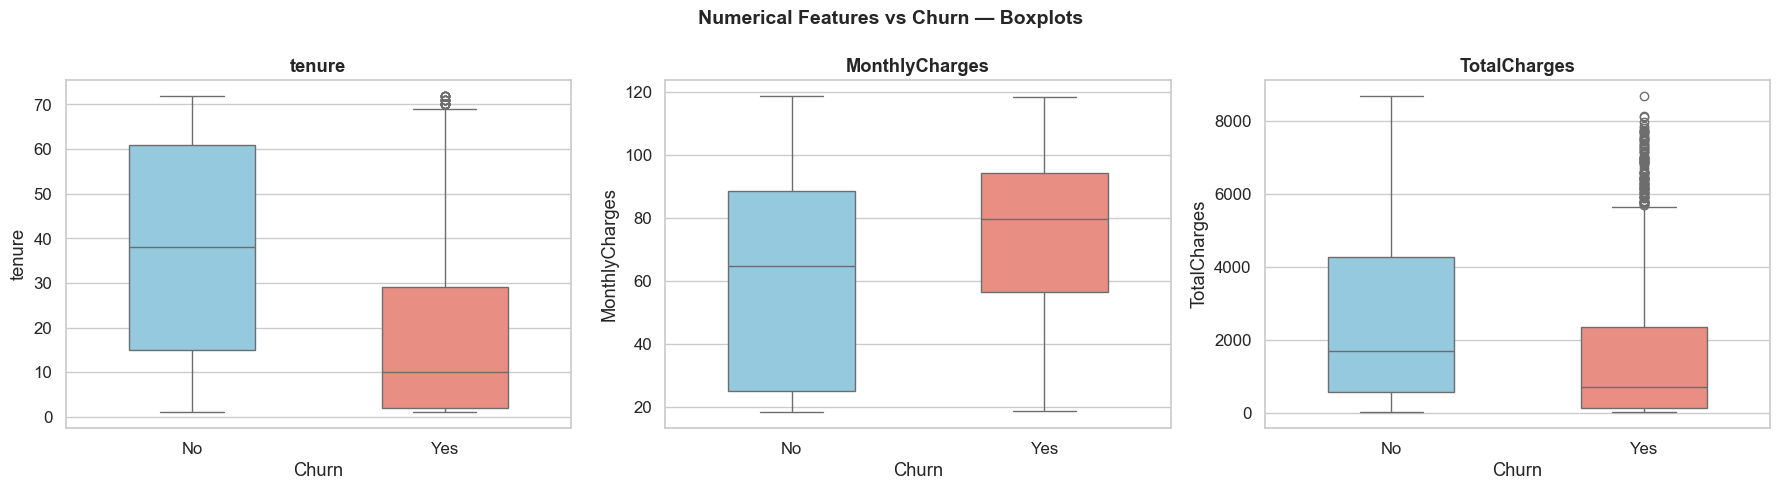

In [17]:
# ── Boxplots: Numerical vs Churn ──
CHURN_PALETTE = {"No": "skyblue", "Yes": "salmon"}

fig, axes = plt.subplots(1, len(numerical_cols), figsize=(6 * len(numerical_cols), 5))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(x=df[TARGET].map({0: 'No', 1: 'Yes'}),
                y=df[col],
                palette=CHURN_PALETTE, ax=axes[i], width=0.5)
    axes[i].set_title(f'{col}', fontweight='bold')
    axes[i].set_xlabel('Churn')

plt.suptitle('Numerical Features vs Churn — Boxplots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Key Insights — Numerical vs Target:**
- **`tenure`**: Churned customers have significantly **lower tenure** (median ~10 months vs ~38 months for non-churned).
- **`MonthlyCharges`**: Churned customers pay **higher monthly charges** — likely due to more expensive plans with shorter commitment.
- **`TotalCharges`**: Churned customers have lower total charges — consistent with shorter tenure.

### 5.4 Bivariate Analysis — Categorical vs Target

In [18]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
def plot_grouped(cols, title_prefix, figsize=(18, 10)):
    n_c = 3
    n_r = (len(cols) + n_c - 1) // n_c
    fig, axes = plt.subplots(n_r, n_c, figsize=figsize)
    axes = axes.flatten()
    for i, col in enumerate(cols):
        series = df[col].replace({0: 'No', 1: 'Yes'}) if col == 'SeniorCitizen' else df[col]
        cross = pd.crosstab(
            series,
            df[TARGET].map({0: 'No', 1: 'Yes'}),
            normalize='index'
        ) * 100
        cross.plot(kind='bar', stacked=True, ax=axes[i],
                   color=[CHURN_PALETTE['No'], CHURN_PALETTE['Yes']],
                   edgecolor='white', legend=(i == 0))
        axes[i].set_title(col)
        axes[i].set_ylabel('Churn %')
        axes[i].tick_params(axis='x', rotation=0)
        axes[i].set_ylim(0, 100)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle(f'{title_prefix}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

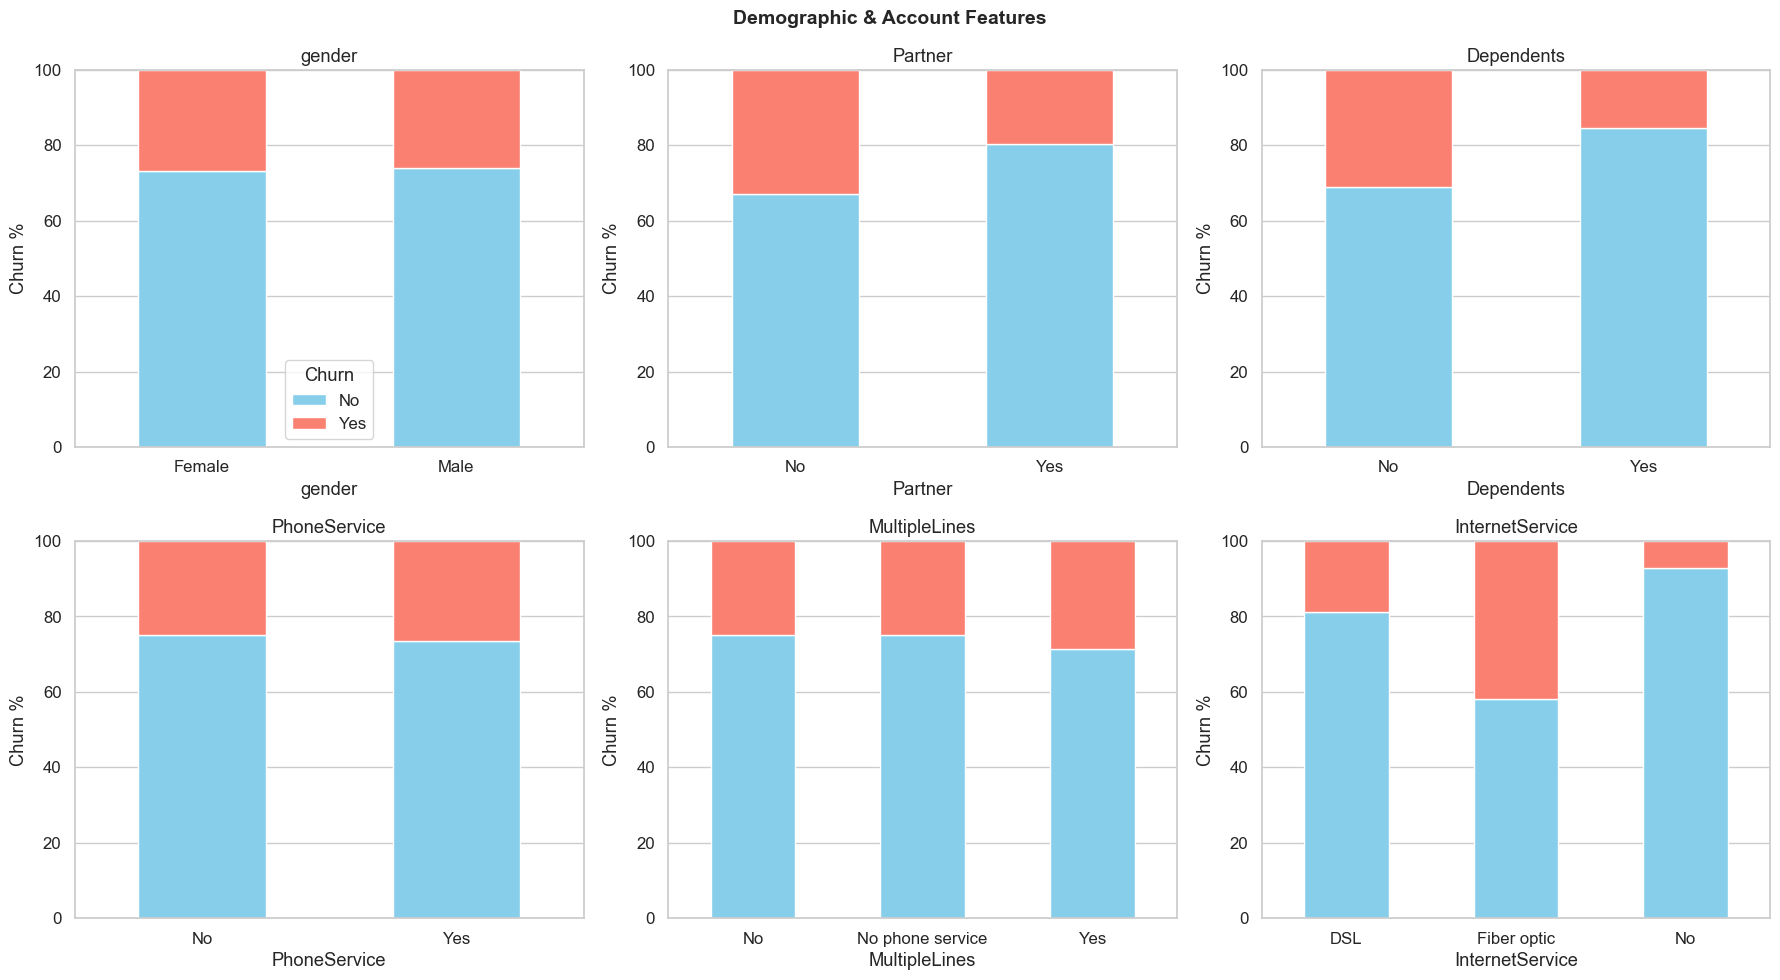

In [19]:
plot_grouped(categorical_cols[:6], 'Demographic & Account Features')

- **`Gender`**: Gender does not appear to be a strong driver of churn
- **`SeniorCitizen`**: senior customers are more likely to leave.
- **`Partner & Dependents`**: Customers without family ties may be more churn‑prone.

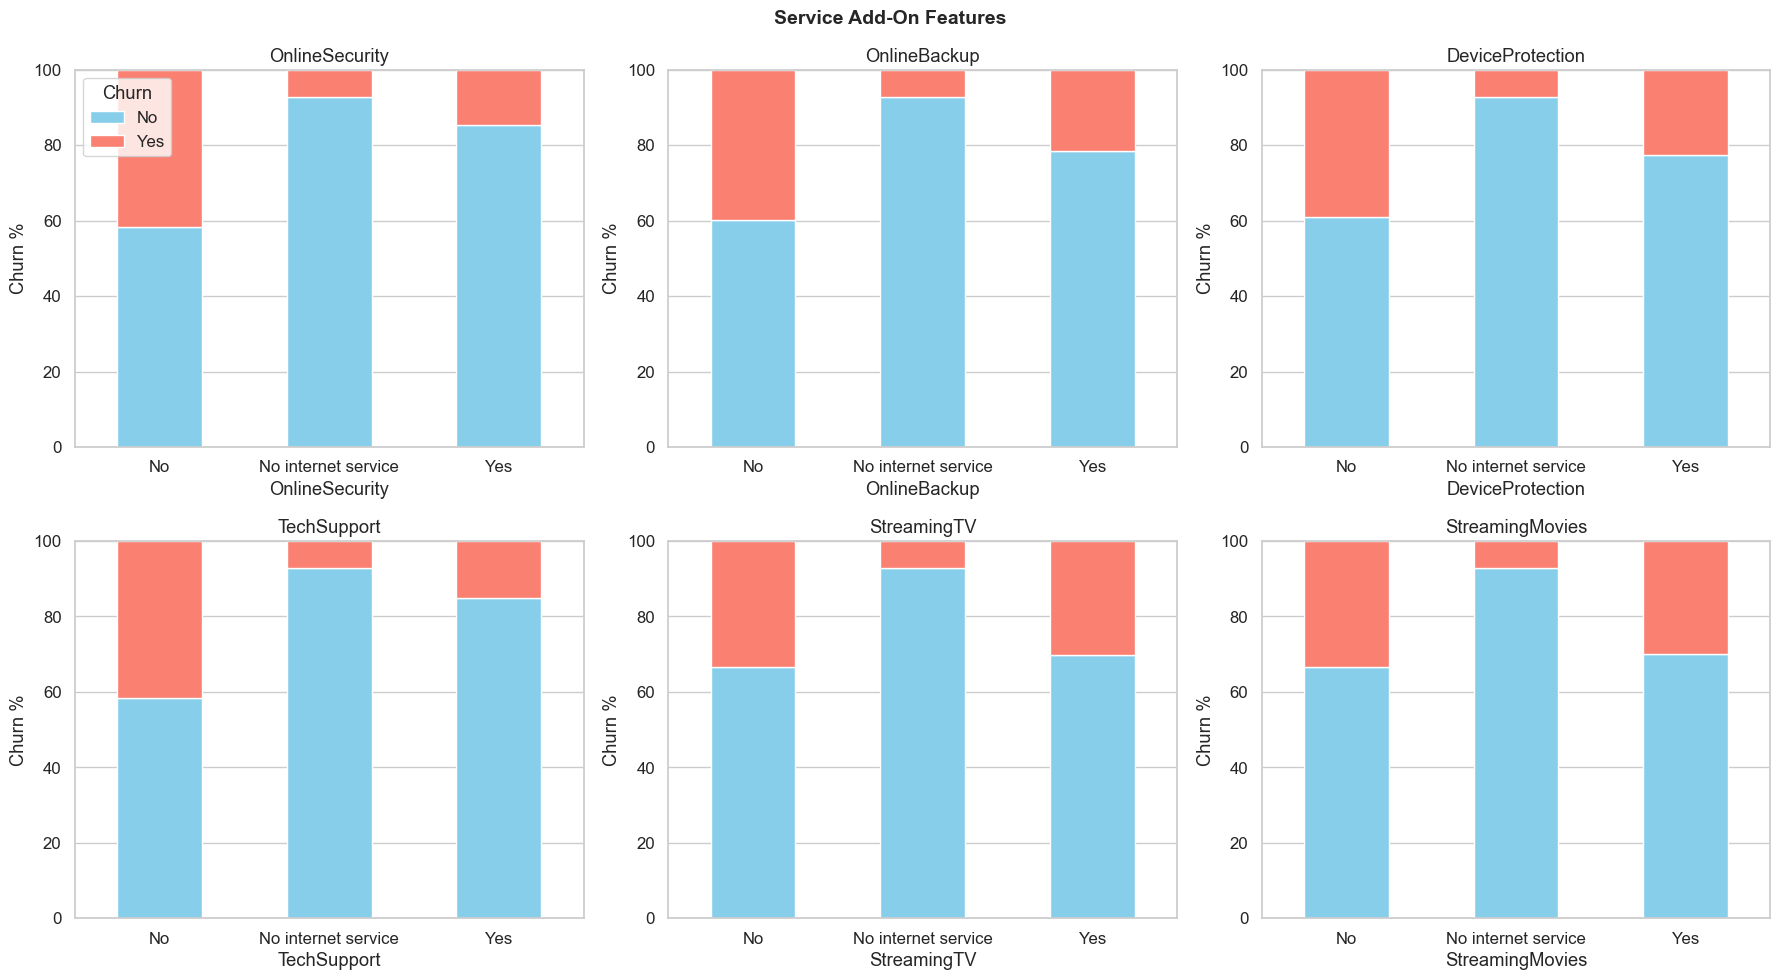

In [20]:
plot_grouped(categorical_cols[6:12], 'Service Add-On Features')

- **`Security/Support Add‑ons (OnlineSecurity, TechSupport, DeviceProtection, Backup)`**: Most customers do not subscribe (65-71% “No”) → Lack of add‑ons correlates with higher churn; upselling these could improve retention.
- **`Streaming Services (TV & Movies)`**: Adoption is moderate (~35–40% “Yes”). → Entertainment bundles may reduce churn by increasing engagement.

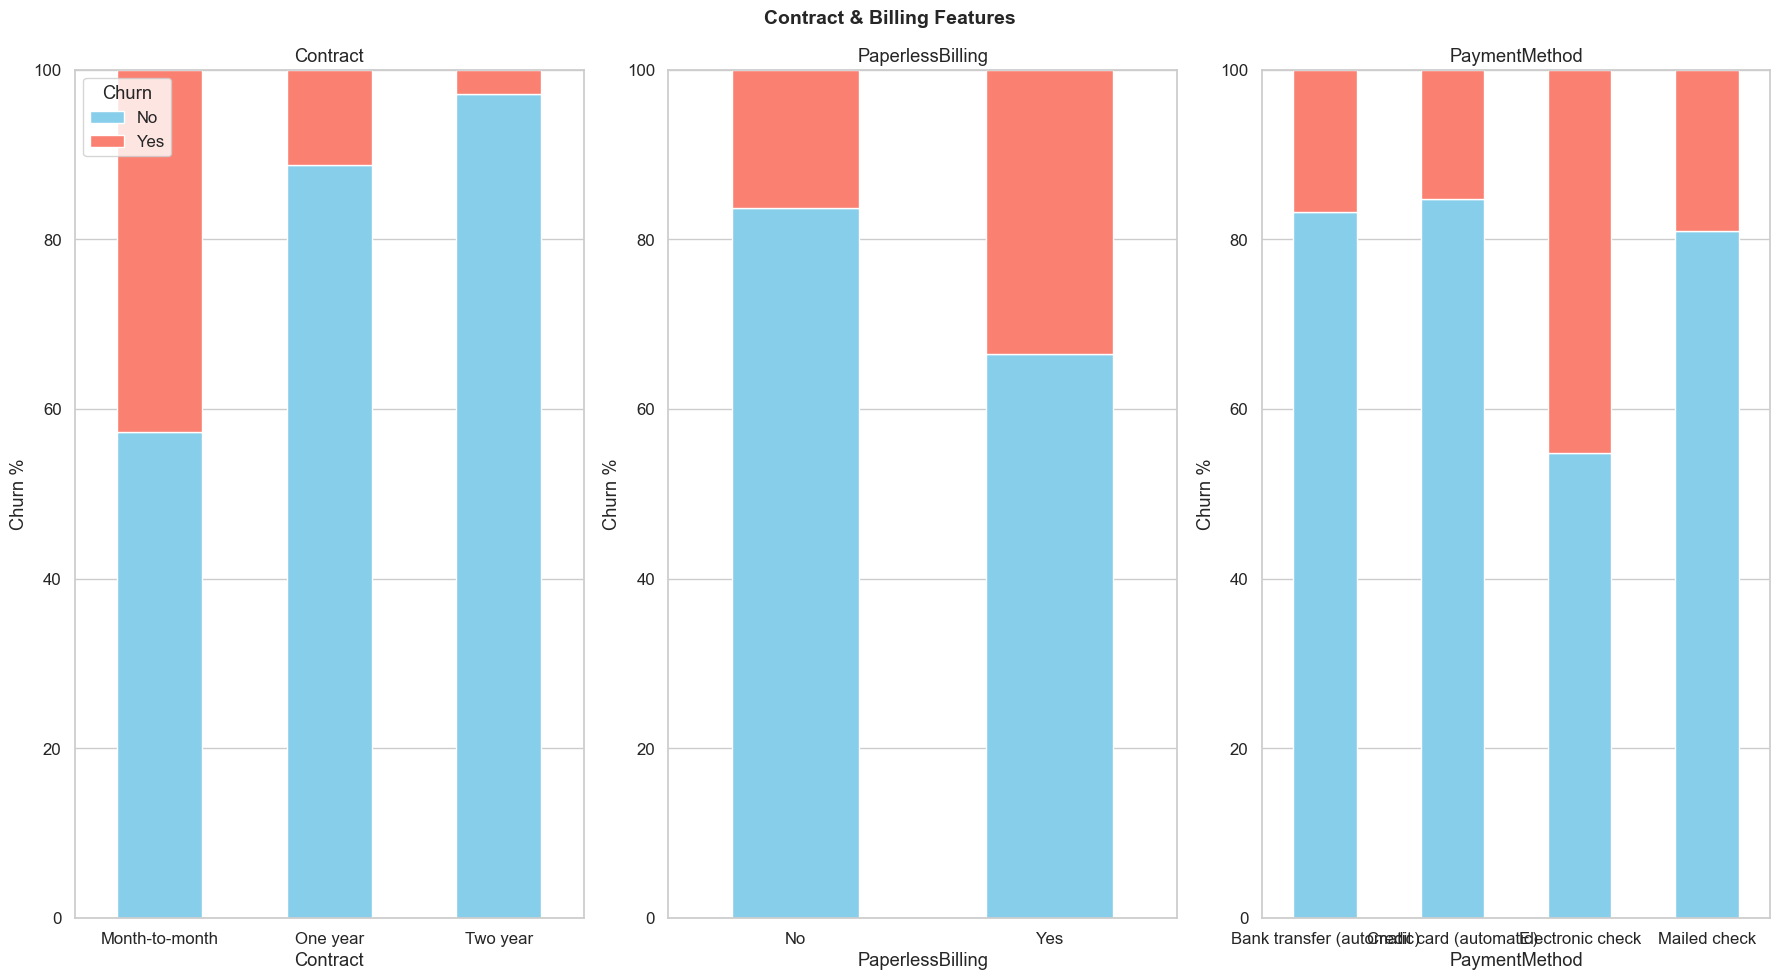

In [21]:
plot_grouped(categorical_cols[12:], 'Contract & Billing Features')

**Key Insights — Categorical vs Target:**
- **`SeniorCitizen`**: Seniors churn at a notably higher rate than non-seniors.
- **`InternetService`**: `Fiber optic` customers churn at ~42% — possibly dissatisfied with quality or price relative to cost.
- **`OnlineSecurity`, `TechSupport`**: Customers without these add-ons churn at ~2× the rate of those with them — add-ons increase switching cost.
- **`Contract`**: `Month-to-month` customers churn at ~43% vs ~11% for one-year and ~3% for two-year.
- **`PaymentMethod`**: `Electronic check` users show disproportionately high churn (~45%).

### 5.5 Bivariate Analysis — Numerical vs Numerical (Correlation)

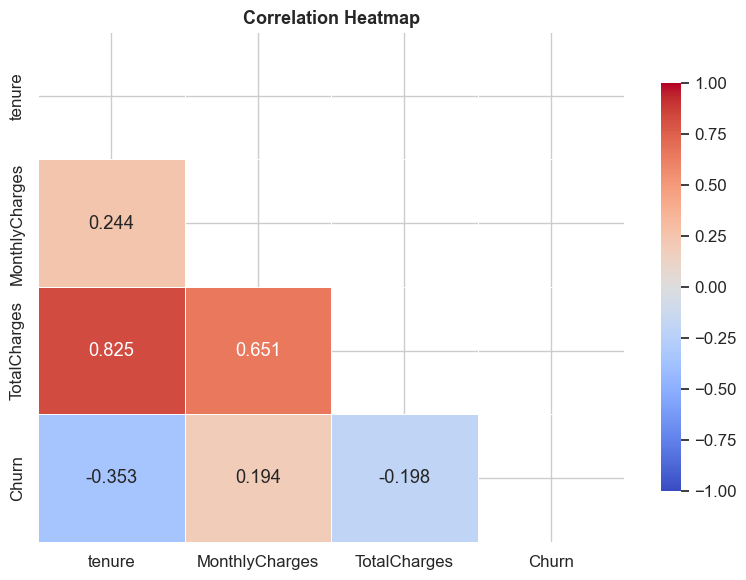


--- Multicollinearity Check (|r| > 0.8) ---
⚠️ HIGH CORRELATION: tenure ↔ TotalCharges  r = 0.825


In [22]:
# ── Correlation heatmap ──
corr_matrix = df[numerical_cols + [TARGET]].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', vmin=-1, vmax=1,
            annot=True, fmt='.3f', linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

# ── Multicollinearity warning ──
print("\n--- Multicollinearity Check (|r| > 0.8) ---")
found = False
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.8:
            print(f"⚠️ HIGH CORRELATION: {corr_matrix.columns[i]} ↔ {corr_matrix.columns[j]}  r = {r:.3f}")
            found = True
if not found:
    print("✅ No pair exceeds the 0.8 threshold — no severe multicollinearity detected.")

### 5.6 Target Variable Analysis

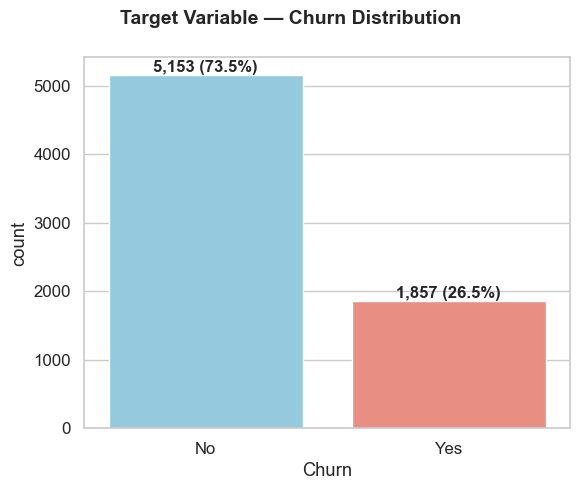

Imbalance ratio -> 2.77 : 1


In [23]:
# Count plot
plt.figure(figsize=(6, 5))
target_mapped = df[TARGET].map({0: 'No', 1: 'Yes'})
sns.countplot(x=target_mapped, palette=CHURN_PALETTE, edgecolor='white')
total = len(df)
for p in plt.gca().patches:
    count = int(p.get_height())
    pct = count / total * 100
    plt.annotate(f'{count:,} ({pct:.1f}%)',
                 (p.get_x() + p.get_width()/2., p.get_height()),
                 ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.suptitle('Target Variable — Churn Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

churn_counts = target_mapped.value_counts()
print(f"Imbalance ratio -> {churn_counts['No']/churn_counts['Yes']:.2f} : 1")

## 6. Feature Engineering

In [24]:
df_fe = df.copy()

# ── Feature 1: Number of Active Add-on Services ──
# Customers with more add-ons have higher switching costs → lower churn risk
addon_cols = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]
df_fe['NumAddons'] = (df_fe[addon_cols] == 'Yes').sum(axis=1)

# ── Feature 2: Is New Customer ──
# New customers (tenure ≤ 3 months) are at highest risk of early churn
df_fe['IsNewCustomer'] = (df_fe['tenure'] <= 3).astype(int)

print("New features created:")
print(f"  NumAddons       — count of active add-on services (range 0–6)")
print(f"  IsNewCustomer   — 1 if tenure ≤ 3 months, else 0")
print(f"\nUpdated shape: {df_fe.shape}")
df_fe[['NumAddons', 'IsNewCustomer']].head()

New features created:
  NumAddons       — count of active add-on services (range 0–6)
  IsNewCustomer   — 1 if tenure ≤ 3 months, else 0

Updated shape: (7010, 22)


,NumAddons,IsNewCustomer
0,1,1
1,2,0
2,2,1
3,3,0
4,0,1


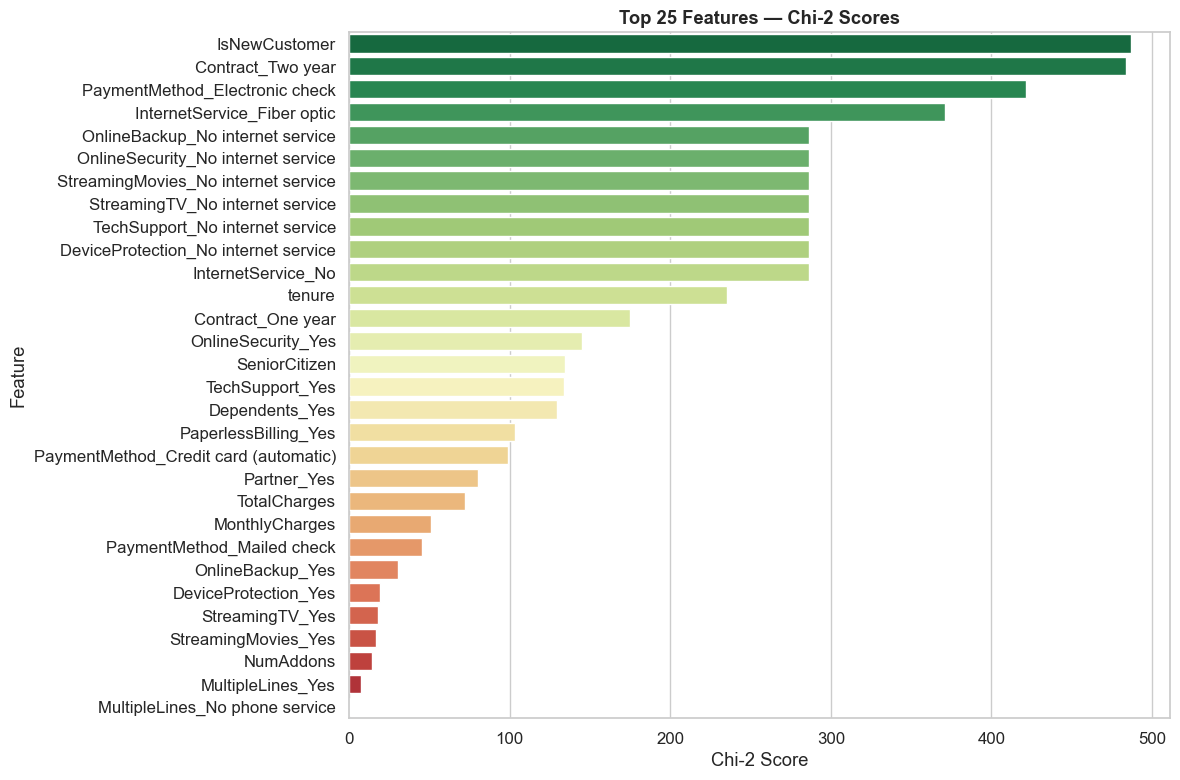

In [25]:
# ── Feature Importance via SelectKBest (Chi-2) ──
# Filter-based ranking using Chi-2 test on the full feature set after OHE.

X_fe = pd.get_dummies(df_fe.drop(columns=[TARGET]), drop_first=True)
y_fe = df_fe[TARGET]

# Chi-2 requires non-negative values — apply MinMaxScaler first
X_fe_scaled = MinMaxScaler().fit_transform(X_fe)

kb = SelectKBest(chi2, k='all')
kb.fit(X_fe_scaled, y_fe)

feat_scores = pd.DataFrame({
    'Feature':    X_fe.columns,
    'Chi2_Score': kb.scores_
}).sort_values('Chi2_Score', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(x='Chi2_Score', y='Feature', data=feat_scores.head(30),
            palette='RdYlGn_r', ax=ax, edgecolor='white')
ax.set_title('Top 25 Features — Chi-2 Scores', fontweight='bold')
ax.set_xlabel('Chi-2 Score')
plt.tight_layout()
plt.show()

In [26]:
# Identify final feature groups

num_features = [c for c in df_fe.select_dtypes(include=['int64','float64']).columns
                if c != TARGET]
cat_features  = list(df_fe.select_dtypes(include=['object','category']).columns)

FEATURE_COLS = num_features + cat_features
print(f"Total features: {len(FEATURE_COLS)}")
print(f"\nNumerical  ({len(num_features)}): {num_features}")
print(f"\nCategorical ({len(cat_features)}): {cat_features}")

Total features: 20

Numerical  (5): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'NumAddons']

Categorical (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


### Feature Engineering — Summary
| New Feature | Rationale |
|---|---|
| `NumAddons` | Customers with more add-ons are more entrenched — lower churn risk |
| `IsNewCustomer` | New customers (≤3 months) are highest-risk for early churn |

---
## 7. Data Splitting

In [27]:
X = df_fe[FEATURE_COLS]
y = df_fe[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.20,random_state=RANDOM_STATE,stratify=y)

print("--- Dataset Split Summary ---")
print(f"  Full dataset : {X.shape[0]:>5,} rows")
print(f"  Train set    : {X_train.shape[0]:>5,} rows  ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Test  set    : {X_test.shape[0]:>5,}  rows  ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\n  Features     : {X_train.shape[1]}")

--- Dataset Split Summary ---
  Full dataset : 7,010 rows
  Train set    : 5,608 rows  (80.0%)
  Test  set    : 1,402  rows  (20.0%)

  Features     : 20


**Splitting Notes:**
- Stratified splits preserve the ~26.5% churn rate across all three sets.

---
## 8. PREPROCESSING PIPELINE DESIGN & EVALUATION FUNCTION

Two shared preprocessing pipelines are defined once and reused across all models:

| Pipeline | Numerical step | Categorical step | Used for |
|---|---|---|---|
| `preprocessor_with_scaling` | `StandardScaler` | `OneHotEncoder` | Scale-sensitive models (LR, KNN, SVM) |
| `preprocessor_no_scaling` | `passthrough` | `OneHotEncoder` | Tree-based models (DT, RF, XGB, LGBM) |


In [28]:
# ── Preprocessing Pipeline 1: With Scaling ──
preprocessor_with_scaling = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)],
    remainder='drop')

# ── Preprocessing Pipeline 2: No Scaling ──
preprocessor_no_scaling = ColumnTransformer(
    transformers=[
        ('num', 'passthrough',num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False),cat_features)],
    remainder='drop')

In [29]:
# ── Cross-Validation Evaluation Function ──
def model_cv_evaluation(pipeline, X_tr, y_tr, name, cv=CV_FOLDS):
    cv_strategy = StratifiedKFold(n_splits=cv, shuffle=True, random_state=RANDOM_STATE)
    
    scores = cross_validate(
        pipeline, X_tr, y_tr,
        cv=cv_strategy,
        scoring={
            'Recall':   'recall',
            'Precision':'precision',
            'F1':       'f1',
            'PR_AUC':   'average_precision'
        },
        return_train_score=True,
        n_jobs=-1,
    )

    result = {
        'model':            name,
        'train_Recall':     scores['train_Recall'].mean(),
        'cv_Recall':        scores['test_Recall'].mean(),
        'train_Precision':  scores['train_Precision'].mean(),
        'cv_Precision':     scores['test_Precision'].mean(),
        'train_F1':         scores['train_F1'].mean(),
        'cv_F1':            scores['test_F1'].mean(),
        'train_PR_AUC':     scores['train_PR_AUC'].mean(),
        'cv_PR_AUC':        scores['test_PR_AUC'].mean(),
    }

    pipeline.fit(X_tr, y_tr)

    print(f" Train:     "
          f"Recall={result['train_Recall']:.4f}  Prec={result['train_Precision']:.4f}  F1={result['train_F1']:.4f}  PR-AUC={result['train_PR_AUC']:.4f}")
    print(f" CV {cv}-fold: "
          f"Recall={result['cv_Recall']:.4f}  Prec={result['cv_Precision']:.4f}  F1={result['cv_F1']:.4f}  PR-AUC={result['cv_PR_AUC']:.4f}")

    return result

baseline_results = {}   

---
## 9. Model Training

### Model 1: Logistic Regression

In [30]:
pipe_lr = Pipeline([
    ('pre',   preprocessor_with_scaling),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE))
])

print('Logistic Regression')
baseline_results['LogisticRegression'] = model_cv_evaluation(pipe_lr, X_train, y_train, 'LogisticRegression')

Logistic Regression
 Train:     Recall=0.8122  Prec=0.5199  F1=0.6340  PR-AUC=0.6599
 CV 5-fold: Recall=0.8069  Prec=0.5145  F1=0.6281  PR-AUC=0.6540


### Model 2: K-Nearest Neighbours (KNN)

In [31]:
pipe_knn = Pipeline([
    ('pre',   preprocessor_with_scaling),
    ('model', KNeighborsClassifier(n_jobs=-1))
])

print('KNN Classifier')
baseline_results['KNN'] = model_cv_evaluation(pipe_knn, X_train, y_train, 'KNN')

KNN Classifier
 Train:     Recall=0.6521  Prec=0.7086  F1=0.6791  PR-AUC=0.7157
 CV 5-fold: Recall=0.5343  Prec=0.5517  F1=0.5421  PR-AUC=0.5099


### Model 3: Support Vector Classifier (SVC)

In [32]:
pipe_svc = Pipeline([
    ('pre',   preprocessor_with_scaling),
    ('model', SVC(probability=True,class_weight='balanced', random_state=RANDOM_STATE))
])

print('SVC')
baseline_results['SVC'] = model_cv_evaluation(pipe_svc, X_train, y_train, 'SVC')

SVC
 Train:     Recall=0.8274  Prec=0.5535  F1=0.6632  PR-AUC=0.6859
 CV 5-fold: Recall=0.7766  Prec=0.5177  F1=0.6207  PR-AUC=0.6061


### Model 4: Decision Tree

In [33]:
pipe_dt = Pipeline([
    ('pre',   preprocessor_no_scaling),
    ('model', DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE))
])

print('Decision Tree')
baseline_results['DecisionTree'] = model_cv_evaluation(pipe_dt, X_train, y_train, 'DecisionTree')

Decision Tree
 Train:     Recall=1.0000  Prec=0.9945  F1=0.9972  PR-AUC=1.0000
 CV 5-fold: Recall=0.4906  Prec=0.4808  F1=0.4850  PR-AUC=0.3709


### Model 5: Random Forest

In [34]:
pipe_rf = Pipeline([
    ('pre',   preprocessor_no_scaling),
    ('model', RandomForestClassifier(class_weight='balanced',n_jobs=-1,random_state=RANDOM_STATE))
])

print('Random Forest')
baseline_results['RandomForest'] = model_cv_evaluation(pipe_rf, X_train, y_train, 'RandomForest')

Random Forest
 Train:     Recall=0.9995  Prec=0.9948  F1=0.9971  PR-AUC=0.9998
 CV 5-fold: Recall=0.4711  Prec=0.6219  F1=0.5343  PR-AUC=0.6071


### Model 6: XGBoost

In [35]:
# scale_pos_weight = ratio of negative to positive samples — explicitly handles class imbalance
spw = int((y_train == 0).sum() / (y_train == 1).sum())

pipe_xgb = Pipeline([
    ('pre',   preprocessor_no_scaling),
    ('model', XGBClassifier(scale_pos_weight=spw, random_state=RANDOM_STATE, n_jobs=-1))
])

print('XGBoost')
baseline_results['XGBoost'] = model_cv_evaluation(pipe_xgb, X_train, y_train, 'XGBoost')

XGBoost
 Train:     Recall=0.9881  Prec=0.8735  F1=0.9272  PR-AUC=0.9808
 CV 5-fold: Recall=0.5976  Prec=0.5640  F1=0.5790  PR-AUC=0.6125


### Model 7: LightGBM

In [36]:
pipe_lgbm = Pipeline([
    ('pre',   preprocessor_no_scaling),
    ('model', LGBMClassifier(is_unbalance=True, verbose=-1, n_jobs=-1, random_state=RANDOM_STATE))
])

print('LightGBM')
baseline_results['LightGBM'] = model_cv_evaluation(pipe_lgbm, X_train, y_train, 'LightGBM')

LightGBM
 Train:     Recall=0.9674  Prec=0.6908  F1=0.8059  PR-AUC=0.8825
 CV 5-fold: Recall=0.7288  Prec=0.5422  F1=0.6208  PR-AUC=0.6481


In [37]:
# ── Baseline Comparison Table ──
summary = pd.DataFrame([
    {
        'Model':          r['model'],
        'Train Recall':   round(r['train_Recall'], 4),
        'CV Recall':      round(r['cv_Recall'], 4),
        'Overfitting':    round(r['train_Recall'] - r['cv_Recall'], 4),
        'Train Precision':round(r['train_Precision'], 4),
        'CV Precision':   round(r['cv_Precision'], 4),
        'Train F1':       round(r['train_F1'], 4),
        'CV F1':          round(r['cv_F1'], 4),
        'Train PR-AUC':   round(r['train_PR_AUC'], 4),
        'CV PR-AUC':      round(r['cv_PR_AUC'], 4),
    }
    for r in baseline_results.values()
])

summary = summary.sort_values('CV Recall', ascending=False).reset_index(drop=True)
summary.index += 1
print("--- Baseline Model Comparison — 5-Fold CV on Training Set sorted by CV Recall ---")
pd.DataFrame(summary)

--- Baseline Model Comparison — 5-Fold CV on Training Set sorted by CV Recall ---


,Model,Train Recall,CV Recall,Overfitting,Train Precision,CV Precision,Train F1,CV F1,Train PR-AUC,CV PR-AUC
1,LogisticRegression,0.8122,0.8069,0.0054,0.5199,0.5145,0.6340,0.6281,0.6599,0.6540
2,SVC,0.8274,0.7766,0.0508,0.5535,0.5177,0.6632,0.6207,0.6859,0.6061
3,LightGBM,0.9674,0.7288,0.2385,0.6908,0.5422,0.8059,0.6208,0.8825,0.6481
4,XGBoost,0.9881,0.5976,0.3905,0.8735,0.5640,0.9272,0.5790,0.9808,0.6125
5,KNN,0.6521,0.5343,0.1177,0.7086,0.5517,0.6791,0.5421,0.7157,0.5099
6,DecisionTree,1.0000,0.4906,0.5094,0.9945,0.4808,0.9972,0.4850,1.0000,0.3709
7,RandomForest,0.9995,0.4711,0.5284,0.9948,0.6219,0.9971,0.5343,0.9998,0.6071


---
## 10. Hyperparameter Tuning

Although SVC achieved the second-best performance among the base models, its tuning is skipped because it is computationally expensive and slow to train, and may not scale well if the dataset grows in the future. It also requires tuning multiple parameters (C, gamma, kernel), which greatly increases runtime. Additionally, it lacks interpretability and is not the most effective choice for imbalanced datasets compared to models like XGBoost or Random Forest, so it is used only as a benchmark rather than a primary model.

In [38]:
# ── Logistic Regression ──

cv_strategy = StratifiedKFold(
    n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE
)

param_dist_lr = {
    'model__solver':       ['liblinear', 'saga', 'lbfgs', 'newton-cg'],
    'model__C':            np.logspace(-2, 2, 1000),
    'model__tol':          np.logspace(-5, -2, 1000),
    'model__class_weight': ['balanced', {0:1, 1:3}]
}

rs_lr = RandomizedSearchCV(
    pipe_lr,
    param_distributions=param_dist_lr,
    n_iter=100,
    cv=cv_strategy,
    scoring='recall',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=0
)

rs_lr.fit(X_train, y_train)
best_lr = rs_lr.best_estimator_
print(f"Best Params    : {rs_lr.best_params_}")
print(f"Best CV Recall : {rs_lr.best_score_:.4f}")

print("\nLogistic Regression — Tuned")
tuned_result_lr = model_cv_evaluation(best_lr, X_train, y_train, 'LogisticRegression_Tuned')
print()
pd.DataFrame(rs_lr.cv_results_).sort_values('std_test_score')	

Best Params    : {'model__tol': 0.0008015006961565405, 'model__solver': 'lbfgs', 'model__class_weight': {0: 1, 1: 3}, 'model__C': 18.848434090337953}
Best CV Recall : 0.8257

Logistic Regression — Tuned
 Train:     Recall=0.8289  Prec=0.5086  F1=0.6304  PR-AUC=0.6596
 CV 5-fold: Recall=0.8257  Prec=0.5066  F1=0.6276  PR-AUC=0.6542



,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__tol,param_model__solver,param_model__class_weight,param_model__C,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
84,0.094645,0.009096,0.023100,0.002042,0.001021,lbfgs,"{0: 1, 1: 3}",2.502640,"{'model__tol': 0.0010209606623060466, 'model__...",0.835017,0.835017,0.825503,0.804714,0.828283,0.825707,0.011142,1
22,0.452393,0.062893,0.022635,0.000527,0.000328,saga,"{0: 1, 1: 3}",3.093788,"{'model__tol': 0.00032848573660300434, 'model_...",0.828283,0.835017,0.822148,0.801347,0.821549,0.821669,0.011271,17
7,0.088691,0.003758,0.022820,0.002978,0.000284,lbfgs,"{0: 1, 1: 3}",2.900430,"{'model__tol': 0.0002840883690183301, 'model__...",0.831650,0.835017,0.822148,0.801347,0.821549,0.822342,0.011737,8
79,0.108516,0.009947,0.020930,0.002965,0.009727,saga,"{0: 1, 1: 3}",0.215443,"{'model__tol': 0.009727203192450537, 'model__s...",0.828283,0.831650,0.822148,0.797980,0.818182,0.819648,0.011803,26
56,0.093194,0.012253,0.025449,0.004861,0.009462,liblinear,"{0: 1, 1: 3}",0.211507,"{'model__tol': 0.009461848194722003, 'model__s...",0.828283,0.831650,0.822148,0.797980,0.814815,0.818975,0.011962,27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,0.158442,0.010814,0.019386,0.001321,0.001172,saga,balanced,0.054042,"{'model__tol': 0.0011723818032865986, 'model__...",0.801347,0.831650,0.802013,0.764310,0.787879,0.797440,0.021888,99
59,0.087637,0.006755,0.022046,0.002430,0.000034,liblinear,balanced,0.018377,"{'model__tol': 3.4240061379714256e-05, 'model_...",0.808081,0.835017,0.802013,0.767677,0.791246,0.800807,0.021971,89
76,0.086515,0.006727,0.023414,0.003826,0.001889,newton-cg,balanced,0.317323,"{'model__tol': 0.0018891927762076663, 'model__...",0.818182,0.828283,0.808725,0.764310,0.794613,0.802822,0.022224,80
85,0.072339,0.009656,0.019872,0.001880,0.006120,lbfgs,"{0: 1, 1: 3}",0.085691,"{'model__tol': 0.0061204983724766964, 'model__...",0.818182,0.831650,0.798658,0.764310,0.801347,0.802829,0.022670,79


In [39]:
# ── XGBoost ──

param_dist_xgb = {
    'model__n_estimators':     [400, 600, 800],
    'model__learning_rate':    [0.01, 0.05, 0.1],
    'model__max_depth':        [3, 4, 6],
    'model__subsample':        [0.7, 0.85, 1.0],
    'model__colsample_bytree': [0.7, 0.85, 1.0],
    'model__gamma':            [0, 0.1, 0.3],
    'model__reg_alpha':        [0, 0.1, 1.0],
}


rs_xgb = RandomizedSearchCV(
    pipe_xgb,
    param_distributions=param_dist_xgb,
    n_iter=100,
    cv=cv_strategy,
    scoring='recall',
    n_jobs=-1,
    verbose=0,
    random_state=RANDOM_STATE
)
rs_xgb.fit(X_train, y_train)
best_xgb = rs_xgb.best_estimator_
print(f'Best Params    : {rs_xgb.best_params_}')
print(f'Best CV Recall : {rs_xgb.best_score_:.4f}')
print('\nXGBoost — Tuned')
tuned_result_xgb = model_cv_evaluation(best_xgb, X_train, y_train, 'XGBoost_Tuned')
print()
pd.DataFrame(rs_xgb.cv_results_).sort_values('std_test_score')

Best Params    : {'model__subsample': 0.85, 'model__reg_alpha': 1.0, 'model__n_estimators': 600, 'model__max_depth': 3, 'model__learning_rate': 0.01, 'model__gamma': 0.1, 'model__colsample_bytree': 0.7}
Best CV Recall : 0.7275

XGBoost — Tuned
 Train:     Recall=0.7571  Prec=0.5944  F1=0.6659  PR-AUC=0.7097
 CV 5-fold: Recall=0.7275  Prec=0.5711  F1=0.6391  PR-AUC=0.6733



,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__subsample,param_model__reg_alpha,param_model__n_estimators,param_model__max_depth,param_model__learning_rate,param_model__gamma,param_model__colsample_bytree,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
33,0.678639,0.052848,0.036541,0.004941,0.70,0.0,400,3,0.01,0.3,0.70,"{'model__subsample': 0.7, 'model__reg_alpha': ...",0.764310,0.760943,0.684564,0.670034,0.727273,0.721425,0.038561,5
46,1.371834,0.059753,0.051718,0.005889,0.70,0.1,600,6,0.10,0.1,0.70,"{'model__subsample': 0.7, 'model__reg_alpha': ...",0.548822,0.622896,0.573826,0.498316,0.555556,0.559883,0.040241,99
22,0.948746,0.091142,0.037956,0.004571,0.85,1.0,600,3,0.01,0.1,0.70,"{'model__subsample': 0.85, 'model__reg_alpha':...",0.760943,0.784512,0.684564,0.683502,0.723906,0.727485,0.040401,1
92,0.707513,0.035774,0.034953,0.001415,1.00,0.1,800,3,0.05,0.3,0.70,"{'model__subsample': 1.0, 'model__reg_alpha': ...",0.744108,0.781145,0.687919,0.666667,0.720539,0.720075,0.040481,9
3,1.432854,0.040021,0.035064,0.003934,1.00,0.0,600,3,0.05,0.0,1.00,"{'model__subsample': 1.0, 'model__reg_alpha': ...",0.723906,0.767677,0.671141,0.653199,0.693603,0.701905,0.040491,41
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,0.762366,0.024028,0.036537,0.002812,1.00,1.0,800,6,0.05,0.3,0.85,"{'model__subsample': 1.0, 'model__reg_alpha': ...",0.730640,0.781145,0.647651,0.626263,0.670034,0.691146,0.056933,54
97,1.021255,0.035731,0.032918,0.006149,0.70,0.0,400,6,0.01,0.1,0.70,"{'model__subsample': 0.7, 'model__reg_alpha': ...",0.750842,0.781145,0.637584,0.643098,0.680135,0.698561,0.057771,43
84,0.666038,0.024770,0.037275,0.001092,1.00,0.0,400,6,0.10,0.0,0.70,"{'model__subsample': 1.0, 'model__reg_alpha': ...",0.632997,0.696970,0.580537,0.521886,0.606061,0.607690,0.057816,91
9,1.576883,0.143966,0.046069,0.003028,0.85,1.0,600,6,0.01,0.1,1.00,"{'model__subsample': 0.85, 'model__reg_alpha':...",0.737374,0.777778,0.627517,0.636364,0.673401,0.690487,0.058317,56


In [40]:
# ─ LightGBM ─

param_dist_lgbm = {
    'model__n_estimators':     [200, 300, 400],
    'model__learning_rate':    [0.01, 0.05, 0.1],
    'model__max_depth':        [-1, 5, 10],
    'model__num_leaves':       [31, 63],
    'model__subsample':        [0.7, 0.85, 1.0],
    'model__colsample_bytree': [0.7, 0.85, 1.0],
    'model__reg_lambda':       [0, 0.1, 1.0],
}

rs_lgbm = RandomizedSearchCV(
    pipe_lgbm,
    param_distributions=param_dist_lgbm,
    n_iter=100,
    cv=cv_strategy,
    scoring='recall',
    n_jobs=-1,
    verbose=0,
    random_state=RANDOM_STATE
)
rs_lgbm.fit(X_train, y_train)
best_lgbm = rs_lgbm.best_estimator_
print(f'Best Params    : {rs_lgbm.best_params_}')
print(f'Best CV Recall : {rs_lgbm.best_score_:.4f}')

print('\nLightGBM — Tuned')
tuned_result_lgbm = model_cv_evaluation(best_lgbm, X_train, y_train, 'LightGBM_Tuned')
print()
pd.DataFrame(rs_lgbm.cv_results_).sort_values('std_test_score')

Best Params    : {'model__subsample': 1.0, 'model__reg_lambda': 0.1, 'model__num_leaves': 31, 'model__n_estimators': 400, 'model__max_depth': 5, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.85}
Best CV Recall : 0.7840

LightGBM — Tuned
 Train:     Recall=0.8583  Prec=0.5819  F1=0.6936  PR-AUC=0.7603
 CV 5-fold: Recall=0.7840  Prec=0.5386  F1=0.6378  PR-AUC=0.6610



,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__subsample,param_model__reg_lambda,param_model__num_leaves,param_model__n_estimators,param_model__max_depth,param_model__learning_rate,param_model__colsample_bytree,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
33,5.207153,0.046811,0.018782,0.001079,0.85,0.1,31,300,5,0.01,0.70,"{'model__subsample': 0.85, 'model__reg_lambda'...",0.808081,0.821549,0.771812,0.740741,0.764310,0.781298,0.029533,5
85,7.511847,0.513877,0.023725,0.002796,1.00,1.0,31,400,5,0.01,0.85,"{'model__subsample': 1.0, 'model__reg_lambda':...",0.818182,0.818182,0.771812,0.737374,0.774411,0.783992,0.030826,2
98,3.003040,0.066202,0.018658,0.001067,0.85,0.1,31,200,5,0.05,0.70,"{'model__subsample': 0.85, 'model__reg_lambda'...",0.787879,0.808081,0.768456,0.713805,0.760943,0.767833,0.031587,10
62,3.655314,0.039305,0.019352,0.001546,1.00,0.0,63,200,5,0.01,0.70,"{'model__subsample': 1.0, 'model__reg_lambda':...",0.797980,0.804714,0.741611,0.720539,0.767677,0.766504,0.032201,14
79,3.671175,0.019292,0.018785,0.000514,1.00,0.1,31,200,5,0.01,0.70,"{'model__subsample': 1.0, 'model__reg_lambda':...",0.794613,0.801347,0.741611,0.713805,0.767677,0.763810,0.032760,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23,9.358069,0.069453,0.020971,0.001715,1.00,0.0,31,400,-1,0.05,1.00,"{'model__subsample': 1.0, 'model__reg_lambda':...",0.723906,0.781145,0.671141,0.585859,0.653199,0.683050,0.065986,73
29,14.021022,0.110205,0.021279,0.000824,1.00,1.0,63,300,-1,0.05,1.00,"{'model__subsample': 1.0, 'model__reg_lambda':...",0.696970,0.774411,0.640940,0.579125,0.632997,0.664888,0.066288,80
53,9.451064,0.043774,0.020168,0.000917,1.00,0.0,31,400,-1,0.10,1.00,"{'model__subsample': 1.0, 'model__reg_lambda':...",0.643098,0.730640,0.600671,0.525253,0.616162,0.623165,0.066468,93
0,9.243368,2.560189,0.023052,0.001083,0.70,1.0,31,300,-1,0.10,1.00,"{'model__subsample': 0.7, 'model__reg_lambda':...",0.707071,0.754209,0.647651,0.548822,0.653199,0.662190,0.068741,82


### Tuning Summary — Select Best Model

In [41]:
# ── Tuned Model Comparison Table ──
tuned_candidates = {
    'LogisticRegression_Tuned': (best_lr,   rs_lr.best_score_,   tuned_result_lr),
    'XGBoost_Tuned':            (best_xgb,  rs_xgb.best_score_,  tuned_result_xgb),
    'LightGBM_Tuned':           (best_lgbm, rs_lgbm.best_score_, tuned_result_lgbm),
}

# ── Detailed metrics table ──
summary_tuned = pd.DataFrame([
    {
        'Model':           r['model'],
        'Train Recall':    round(r['train_Recall'], 4),
        'CV Recall':       round(r['cv_Recall'], 4),
        'Overfitting':    round(r['train_Recall'] - r['cv_Recall'], 4),
        'Train Precision': round(r['train_Precision'], 4),
        'CV Precision':    round(r['cv_Precision'], 4),
        'Train F1':        round(r['train_F1'], 4),
        'CV F1':           round(r['cv_F1'], 4),
        'Train PR-AUC':    round(r['train_PR_AUC'], 4),
        'CV PR-AUC':       round(r['cv_PR_AUC'], 4),
    }
    for _, _, r in tuned_candidates.values()
]).sort_values('CV Recall', ascending=False).reset_index(drop=True)
summary_tuned.index += 1
print("--- Tuned Model Comparison — 5-Fold CV on Training Set sorted by CV Recall ---")
display(summary_tuned)

# ── Automatically pick the best ──
best_model_name, (best_pipeline, best_score, _) = max(
    tuned_candidates.items(), key=lambda x: x[1][1]
)
print(f'\nBest model selected: {best_model_name}')

--- Tuned Model Comparison — 5-Fold CV on Training Set sorted by CV Recall ---


,Model,Train Recall,CV Recall,Overfitting,Train Precision,CV Precision,Train F1,CV F1,Train PR-AUC,CV PR-AUC
1,LogisticRegression_Tuned,0.8289,0.8257,0.0032,0.5086,0.5066,0.6304,0.6276,0.6596,0.6542
2,LightGBM_Tuned,0.8583,0.7840,0.0743,0.5819,0.5386,0.6936,0.6378,0.7603,0.6610
3,XGBoost_Tuned,0.7571,0.7275,0.0296,0.5944,0.5711,0.6659,0.6391,0.7097,0.6733



Best model selected: LogisticRegression_Tuned


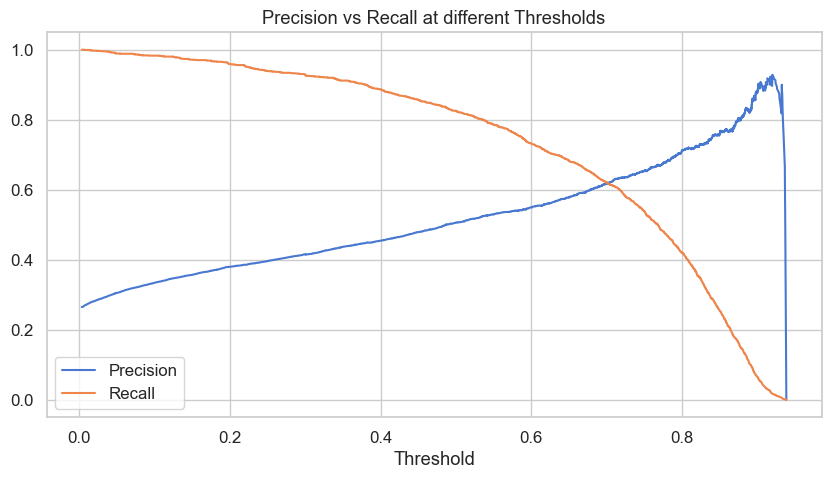

In [42]:
y_probs = cross_val_predict(
    best_pipeline, X_train, y_train,
    cv=CV_FOLDS, method='predict_proba'
)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_train, y_probs)
plt.figure(figsize=(10, 5))
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.xlabel("Threshold")
plt.legend()
plt.title("Precision vs Recall at different Thresholds")
plt.show()

---
## 11. Final Evaluation of the Best Model (Test set)

In [43]:
THRESHOLD = 0.40
y_test_prob = best_pipeline.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_prob >= THRESHOLD).astype(int)

print(f"Evaluating {best_model_name} on test set @ Threshold={THRESHOLD}")
print("=" * 50)
print(classification_report(y_test, y_test_pred, target_names=['No Churn', 'Churned']))
print(f"PR-AUC  : {average_precision_score(y_test, y_test_prob):.4f}")
print(f"ROC-AUC : {roc_auc_score(y_test, y_test_prob):.4f}")

Evaluating LogisticRegression_Tuned on test set @ Threshold=0.4
              precision    recall  f1-score   support

    No Churn       0.94      0.64      0.76      1031
     Churned       0.47      0.89      0.61       371

    accuracy                           0.70      1402
   macro avg       0.70      0.76      0.68      1402
weighted avg       0.81      0.70      0.72      1402

PR-AUC  : 0.6415
ROC-AUC : 0.8462


#### Keep threshold at 0.4 to prioritize catching churners:
- Maximizing detection of potential churners → very high recall for Churned
- Even if offers reach Non-Churn customers → it can boost their loyalty, which is acceptable
- The rationale: losing a customer is costlier than giving an extra offer, so we prefer to act proactively rather than risk attrition

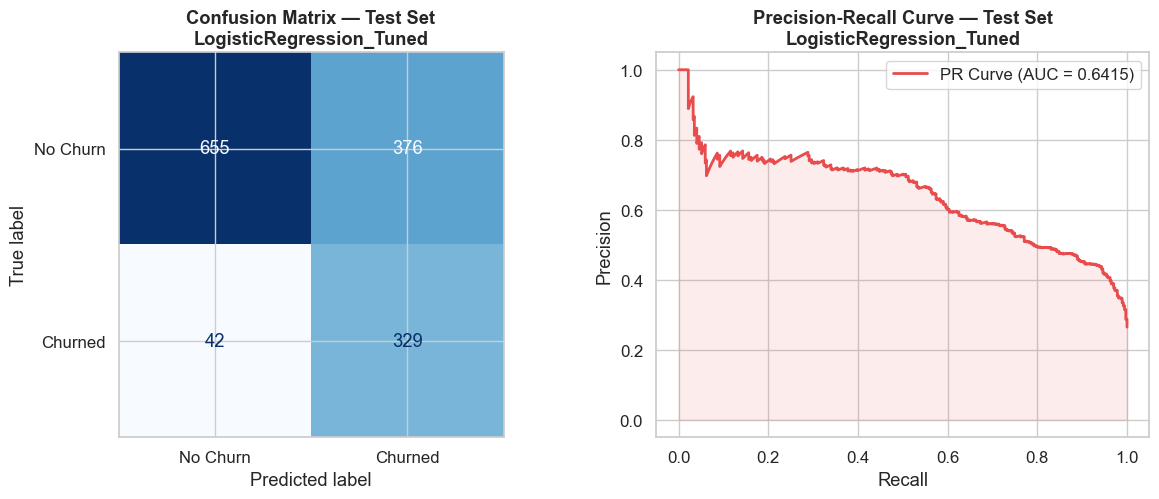

In [44]:
# ── Confusion Matrix ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_test = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(cm_test, display_labels=['No Churn', 'Churned'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Confusion Matrix — Test Set\n{best_model_name}', fontweight='bold')

# ── PR Curve ──
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_test_prob)
pr_auc = average_precision_score(y_test, y_test_prob)

axes[1].plot(recall_vals, precision_vals, color='#E84C4C', lw=2,
             label=f'PR Curve (AUC = {pr_auc:.4f})')
axes[1].fill_between(recall_vals, precision_vals, alpha=0.1, color='#E84C4C')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title(f'Precision-Recall Curve — Test Set\n{best_model_name}', fontweight='bold')
axes[1].legend(loc='upper right')

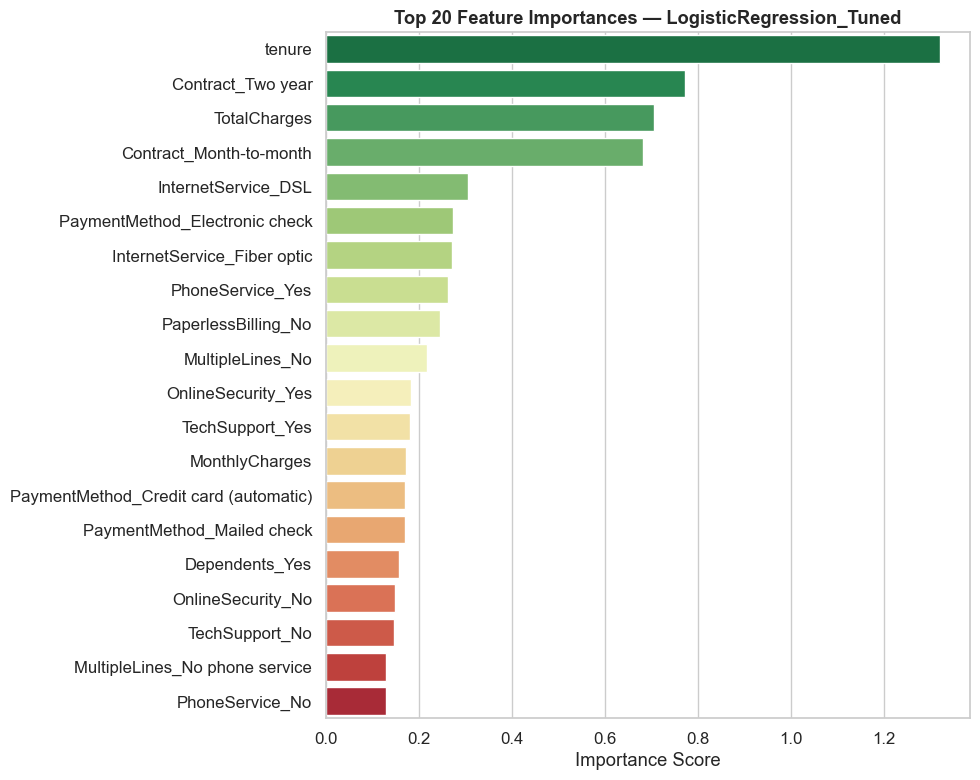

                       Feature  Importance
                        tenure    1.320026
             Contract_Two year    0.772840
                  TotalCharges    0.705996
       Contract_Month-to-month    0.682662
           InternetService_DSL    0.306086
PaymentMethod_Electronic check    0.273886
   InternetService_Fiber optic    0.272263
              PhoneService_Yes    0.262335
           PaperlessBilling_No    0.245345
              MultipleLines_No    0.218979


In [45]:
## Feature Importance — Final Model

# Get feature names after OHE
ohe_feature_names = best_pipeline.named_steps['pre']\
    .named_transformers_['cat'].get_feature_names_out(cat_features).tolist()
all_feature_names = num_features + ohe_feature_names

model_step = best_pipeline.named_steps['model']

# Get importance scores
if hasattr(model_step, 'feature_importances_'):
    importances = model_step.feature_importances_
else:
    importances = np.abs(model_step.coef_[0])

feat_imp_df = pd.DataFrame({
    'Feature':    all_feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).reset_index(drop=True)

top20 = feat_imp_df.head(20)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=top20,
            palette='RdYlGn_r', ax=ax, edgecolor='white')
ax.set_title(f'Top 20 Feature Importances — {best_model_name}', fontweight='bold')
ax.set_xlabel('Importance Score')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

print(feat_imp_df.head(10).to_string(index=False))

---
### Final Evaluation — Analysis
#### LogisticRegression_Tuned — Test Set Summary @ Threshold = 0.4
- **Accuracy**: 70%, **ROC-AUC**: 0.846, **PR-AUC**: 0.642
- **Churned** customers: **Recall** 0.89, **Precision** 0.47 — very good at detecting churners, some false positives are expected
- **Non-churned** customers: **Precision** 0.94, **Recall** 0.64 — mostly correctly identified, a few misclassified, acceptable for retention goals
- **Insight**: Model prioritizes catching potential churners proactively; even if some loyal customers receive offers, this can boost loyalty, and preventing customer loss is more cost-effective than minimizing extra offers

---
## 12. Save the Best Model

In [46]:
# ── Save structured model artifact ──
FEATURE_COLS = list(X_train.columns)
numeric_cols = X_train.select_dtypes(include=['number']).columns

bounds = {
    col: {
        'min': float(X_train[col].min()),
        'max': float(X_train[col].max()),
    }
    for col in numeric_cols
}

artifact = {
    'model': best_pipeline,
    'bounds': bounds,
    'feature_cols': FEATURE_COLS,
    'test_metrics': {
        'pr_auc': average_precision_score(y_test, y_test_prob),
        'roc_auc': roc_auc_score(y_test, y_test_prob),
        'recall': recall_score(y_test, y_test_pred),        
        'precision': precision_score(y_test, y_test_pred),
        'f1': f1_score(y_test, y_test_pred),
        'accuracy': accuracy_score(y_test, y_test_pred),
        'threshold': THRESHOLD,
        },
    'trained_on': str(pd.Timestamp.now().date()),
                                                                                                                                          }
joblib.dump(artifact, MODEL_PATH)
print(f"Model artifact saved to: {MODEL_PATH}")

Model artifact saved to: ../model/best_model_pipeline.pkl


---
# DONE
---